In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [240]:
df=pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [241]:
print(df.shape)
df.drop(columns='Unnamed: 0',axis=1,inplace=True)

(100, 4)


In [242]:
df


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


<Axes: ylabel='iq'>

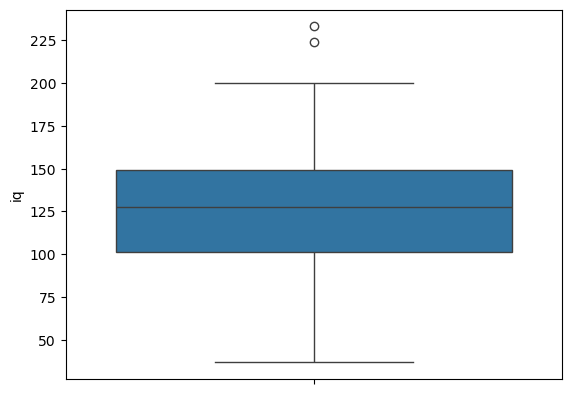

In [243]:
sns.boxplot(df['iq'])

In [244]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [245]:
df['Scaled_iq'] = ((df['iq'] / df['iq'].max()) * 10).round(2)



In [246]:
df.head()

,cgpa,iq,placement,Scaled_iq
0,6.8,123.0,1,5.28
1,5.9,106.0,0,4.55
2,5.3,121.0,0,5.19
3,7.4,132.0,1,5.67
4,5.8,142.0,0,6.09


In [247]:
df.drop(columns='iq',axis=1,inplace=True)

In [248]:
x=df.iloc[:,0:3:2]
y=df.iloc[:,1]

In [249]:
x

,cgpa,Scaled_iq
0,6.8,5.28
1,5.9,4.55
2,5.3,5.19
3,7.4,5.67
4,5.8,6.09
...,...,...
95,4.3,8.58
96,4.4,1.80
97,6.7,7.81
98,6.3,4.42


In [250]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [251]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: xlabel='cgpa', ylabel='Scaled_iq'>

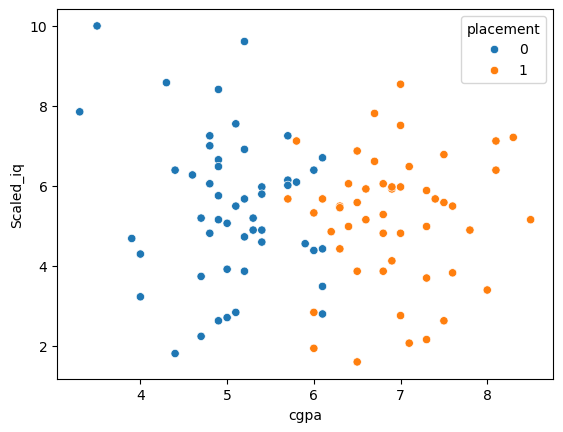

In [252]:
sns.scatterplot(x=df['cgpa'],y=df['Scaled_iq'],hue=df['placement'])

In [253]:
from sklearn.linear_model import Perceptron
P=Perceptron()

In [254]:
P.fit(x_train,y_train)

Perceptron()

In [255]:
y_pred=P.predict(x_test)

In [256]:
P.coef_

array([[16.8 , -7.33]])

In [257]:
P.intercept_

array([-62.])

In [258]:
from mlxtend.plotting import plot_decision_regions

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

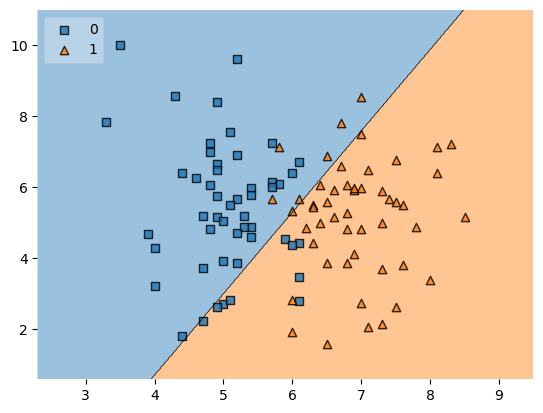

In [259]:
plot_decision_regions(x.values,y.values,clf=P,legend=2)

In [260]:
from sklearn.metrics import accuracy_score


In [261]:
accuracy=accuracy_score(y_test,y_pred)

In [262]:
accuracy*100

95.0